In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/murtozalikhon/skin-cancer-classification/Skin Cancer Detection/valid/mel/ISIC_0031406_jpg.rf.9414d2aee175f4d223da0e1e6e2ec6fc.jpg
/kaggle/input/datasets/murtozalikhon/skin-cancer-classification/Skin Cancer Detection/valid/mel/ISIC_0034173_jpg.rf.416d7e1c0efec326023c401919adcad5.jpg
/kaggle/input/datasets/murtozalikhon/skin-cancer-classification/Skin Cancer Detection/valid/mel/ISIC_0032716_jpg.rf.a46badc1febf493e9f6b571be1e24fbb.jpg
/kaggle/input/datasets/murtozalikhon/skin-cancer-classification/Skin Cancer Detection/valid/mel/ISIC_0032807_jpg.rf.f9a25ed0aacbab1f91b607569f90afdf.jpg
/kaggle/input/datasets/murtozalikhon/skin-cancer-classification/Skin Cancer Detection/valid/mel/ISIC_0027204_jpg.rf.e78425780c28f893d83de3e59ae716e7.jpg
/kaggle/input/datasets/murtozalikhon/skin-cancer-classification/Skin Cancer Detection/valid/mel/ISIC_0024875_jpg.rf.9c8e9c89d52ea7190a5e2e556aed04f7.jpg
/kaggle/input/datasets/murtozalikhon/skin-cancer-classification/Skin Cancer Detect

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import os
from collections import defaultdict
import random

In [3]:
Dataset_path = "/kaggle/input/datasets/murtozalikhon/skin-cancer-classification"
classes = ['akiec','bcc','bkl','df','mel','nv','vasc']
split = ['train','test']

<function matplotlib.pyplot.show(close=None, block=None)>

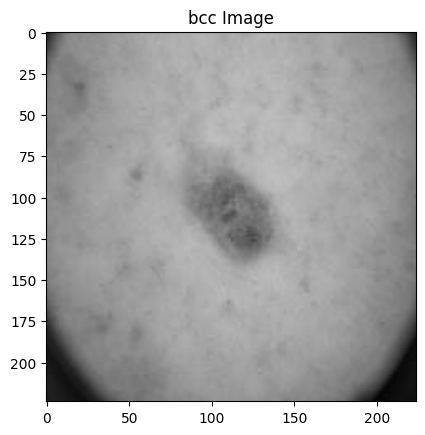

In [4]:
img = Image.open("/kaggle/input/datasets/murtozalikhon/skin-cancer-classification/Skin Cancer Detection/test/bcc/ISIC_0025513_jpg.rf.026c051a94b6226df5692376f106bddf.jpg")
plt.imshow(img)
plt.title('bcc Image')
plt.show

In [5]:
dataset_path = "/kaggle/input/datasets/murtozalikhon/skin-cancer-classification/Skin Cancer Detection/train"
all_img = []
for cls in classes:
    folder = os.path.join(dataset_path,cls)
    for files in os.listdir(folder):
        full_path = os.path.join(folder,files)
        all_img.append((full_path, cls))

print("Total images are: ", len(all_img)) 

Total images are:  13862


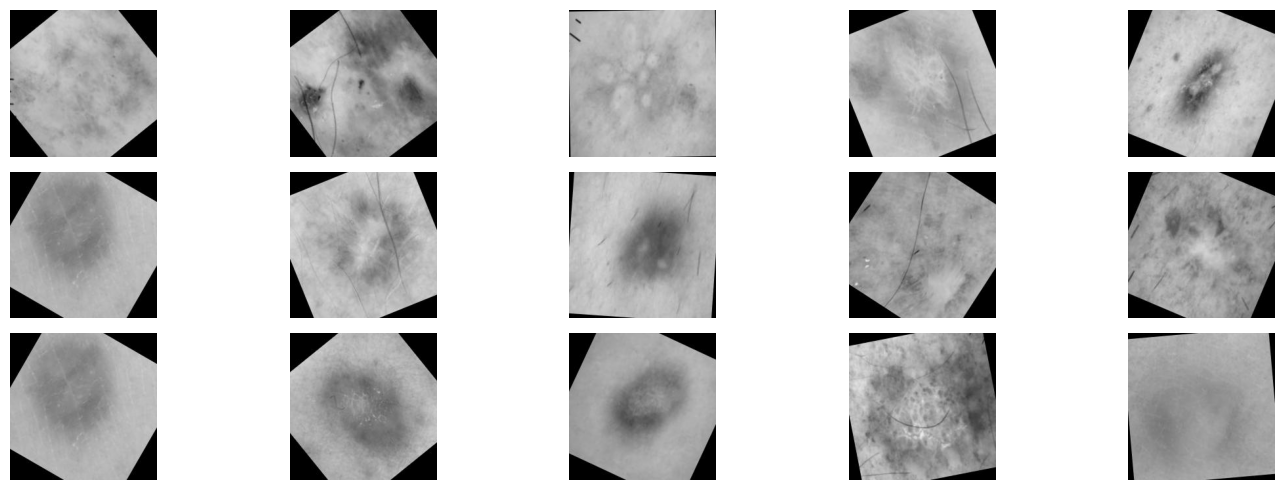

In [6]:
dataset_path = "/kaggle/input/datasets/murtozalikhon/skin-cancer-classification/Skin Cancer Detection/train/df"
files = os.listdir(dataset_path)
fig,axes = plt.subplots(3,5,figsize = (15,5))
for ax in axes.flatten():
    fname= random.choice(files)
    img = Image.open(os.path.join(dataset_path,fname))
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
X,Y=[],[]
base_path = "/kaggle/input/datasets/murtozalikhon/skin-cancer-classification/Skin Cancer Detection/train"
for label,cls in enumerate(classes):
    folder = os.path.join(base_path, cls)
    for fname in os.listdir(folder):
        img = Image.open(os.path.join(folder, fname)).convert("L")
        img = img.resize((128,128))
        X.append(np.array(img))
        Y.append(label)

X = np.array(X)
y = np.array(Y)

print(X.shape)
print(y.shape)

(13862, 128, 128)
(13862,)


In [8]:
X= X/255.0

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 34)
X_train = X_train.reshape(-1,128,128,1)
X_test = X_test.reshape(-1,128,128,1)

print(X_train.shape)
print(X_test.shape)

X_test=X_test.reshape(-1,128,128,1)

(11089, 128, 128, 1)
(2773, 128, 128, 1)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout

model = Sequential([
    Conv2D(32,(4,4), activation = 'relu', input_shape = (128,128,1)),
    MaxPooling2D(2,2),

    Conv2D(64,(4,4), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128,(4,4), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(7,activation='softmax')
])

2026-04-29 17:54:28.533945: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777485268.750395      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777485268.807994      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777485269.314462      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777485269.314522      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777485269.314525      23 computation_placer.cc:177] computation placer alr

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 125, 125, 32)   │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 59, 59, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,934,503 (11.19 MB)

 Trainable params: 2,934,503 (11.19 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
mtrain = model.fit(X_train,y_train, epochs =10, batch_size=32, validation_data = (X_test,y_test))

Epoch 1/10


I0000 00:00:1777485296.152913      74 service.cc:152] XLA service 0x7ee280005700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777485296.152960      74 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777485296.152966      74 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777485296.520286      74 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-29 17:54:58.342011: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 17:54:58.489918: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  7/347 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.3659 - loss: 1.7859

I0000 00:00:1777485300.794117      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


344/347 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6419 - loss: 1.2705

2026-04-29 17:55:08.543480: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 17:55:08.688694: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


347/347 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.6421 - loss: 1.2694 - val_accuracy: 0.6754 - val_loss: 1.0144
Epoch 2/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6662 - loss: 1.0792 - val_accuracy: 0.6751 - val_loss: 0.9821
Epoch 3/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6621 - loss: 1.0492 - val_accuracy: 0.6751 - val_loss: 0.9649
Epoch 4/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6684 - loss: 1.0088 - val_accuracy: 0.6780 - val_loss: 0.9099
Epoch 5/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6585 - loss: 0.9859 - val_accuracy: 0.6855 - val_loss: 0.8720
Epoch 6/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6739 - loss: 0.9446 - val_accuracy: 0.6852 - val_loss: 0.8803
Epoch 7/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6927 - loss: 0.8976 - val_accuracy: 0.7036 - val_loss: 0.8754
Epoch 8/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6977 - loss: 0.8819 - val_accuracy: 0.70

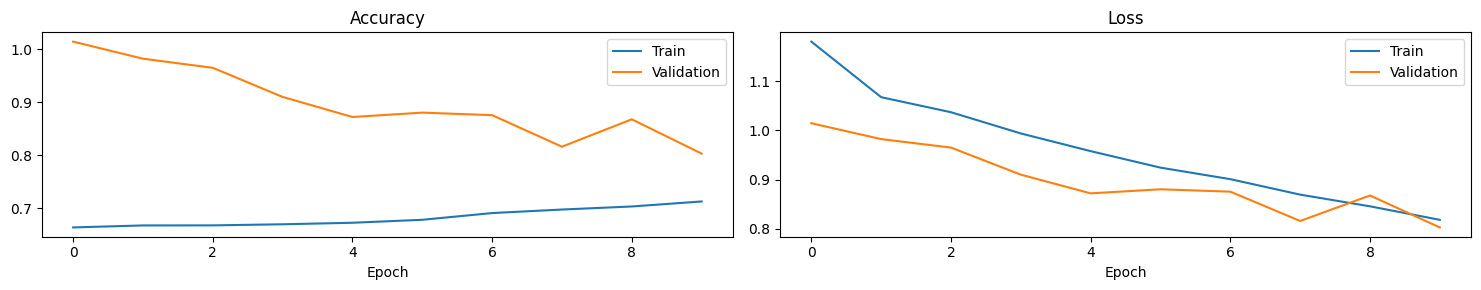

In [14]:
plt.figure(figsize=(15,3))
plt.subplot(1,2,1)
plt.plot(mtrain.history['accuracy'], label='Train')
plt.plot(mtrain.history['val_loss'], label='Validation')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mtrain.history['loss'], label='Train')
plt.plot(mtrain.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
base_path = "/kaggle/input/datasets/murtozalikhon/skin-cancer-classification/Skin Cancer Detection/test"
X_tests,Y_tests=[],[]
for label,cls in enumerate(classes):
    folder = os.path.join(base_path,cls)
    for fname in os.listdir(folder):
        img = Image.open(os.path.join(folder,fname)).convert("L")
        img = img.resize((128,128))
        X_tests.append(np.array(img))
        Y_tests.append(label)

X_tests=np.array(X_tests)/255.0
X_tests = X_tests.reshape(-1,128,128,1)
Y_tests= np.array(Y_tests)

print(X_tests.shape)
print(Y_tests.shape)

(991, 128, 128, 1)
(991,)


In [16]:
loss, accuracy = model.evaluate(X_tests, Y_tests)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4780 - loss: 1.3212
Test Accuracy: 71.44%


In [17]:
for label, cls in enumerate(classes):
    folder = os.path.join(base_path, cls)
    files = os.listdir(folder)
    print(f"{cls}: {len(files)} images")

akiec: 28 images
bcc: 54 images
bkl: 111 images
df: 11 images
mel: 111 images
nv: 668 images
vasc: 8 images
